# Laboratory practice 5

- This .pynb file is ready for execution in a Google Colab (https://colab.research.google.com) environment. Just upload it and open it from a regular Colab session.

- **This lab will be evaluated at the end of the session on April 24 (deadline).**

- In case we do not manage to evaluate all exercises during the lab session, the students will be asked to send the answers of Lab 5 (in PDF format) to the task in Poliformat. (Use the "print" menu option of the Google Colab environment to create a PDF file. **Please name the file with your answers as “Lab5_students_name.pdf”**)

## Quantum Error Correction

Prerequisite

- Slides of Quantum Error Correction lecture

In [3]:
# ALWAYS RUN THIS CELL AFTER YOU LOAD (OR RELOAD) THE NOTEBOOK

# ALWAYS RUN THIS CELL AFTER YOU LOAD (OR RELOAD) THE NOTEBOOK

# Generic cell for correct operation of QCO materials in Google Colab (jcperez@disca.upv.es):
!pip -qqq install qiskit[visualization]
!pip -qqq install qiskit-aer
import qiskit
%matplotlib inline
qiskit.__version__

# Not always necessary (jcperez@disca.upv.es):
!pip -qqq install git+https://github.com/qiskit-community/qiskit-textbook.git#subdirectory=qiskit-textbook-src

# To fix a bug/version incompatibility in that file (jcperez@disca.upv.es):
# !sed -ie 's/denominator >/denominator() >/g' /usr/local/lib/python3.10/dist-packages/qiskit/visualization/array.py

# To set graphical circuit drawing by default in qiskit (jcperez@disca.upv.es):
!mkdir ${HOME}/.qiskit 2>/dev/null
!printf "[default]\ncircuit_drawer = mpl\ncircuit_mpl_style = iqp\n" > ${HOME}/.qiskit/settings.conf

  Preparing metadata (setup.py) ... done


In [4]:
# Do the necessary imports
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import  transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.circuit.library import Initialize
from qiskit_textbook.tools import random_state, array_to_latex
from math import sqrt, pi

<h2 style="font-size:24px;">The 3 qubit bit-flip code</h2>

<br>
<div style="background: #E8E7EB; border-radius: 5px;
-moz-border-radius: 5px;">
  <p style="background: #800080;
            border-radius: 5px 5px 0px 0px;
            padding: 10px 0px 10px 10px;
            font-size:18px;
            color:white;
            "><b>Goal</b></p>
    <p style=" padding: 0px 0px 10px 10px;
              font-size:16px;">Understand how the 3 qubit bit-flip code works.</p>
</div>


As explained in the lecture on quantum error correction, qubits and gates are error prone and therefore quantum error correction protocols are required to protect quantum information. In quantum error correction a logical qubit is encoded into several physical qubits and errors are detected by performing parity check measurements.  

One of the simplest quantum error correction codes is the 3 qubit bit-flip code that can detect and correct single bit-flip errors. As shown in the picture below, 3 qubits are used for encoding the logical qubit (data qubits) and 2 ancilla qubits for extracting the error syndromes.

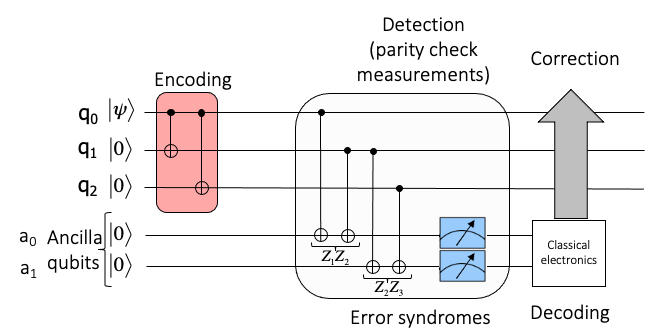

In this first exercise you will have to write the code for 3 qubit bit-flip QEC code and see what happens when different single-qubit errors are injected.




<h3 style="font-size: 20px"> 1. Creating the 3 bit flip-code circuit (0,5 points) </h3>



<h4 style="font-size: 17px">&#128211;Step 1. Encoding a logical qubit.</h4>

We will start by creating a Python function for the encoding part, in which we will initialize $q_0$ to $|\psi \rangle = |1\rangle$ and encode it to a logical qubit $|\psi_L \rangle = |111\rangle$.

In [9]:
def encoding(qc, d0, d1, d2):
    #### qc is the quantum circuit and d0 (q0), d1 (q1) and d2 (q2) are the three data qubits

    #### your code goes here

#initialiaztion of q0 to state 1

  qc.initialize(1, d0)

#encoding CNOT gates

  qc.cx(d0,d1)
  qc.cx(d0,d2)

  qc.barrier()

<h4 style="font-size: 17px">&#128211;Step 2.Detecting bit-flip errors (0,5 points)</h4>

Now, we will create another Pyhton function for the detection part as shown in the picture above.

In [10]:
def detection(qc, d0, d1, d2, a0, a1):
    #### qc is the quantum circuit; d0, d1 and d2 are the three data qubits; a0 (q3) and a1 (q4) are the ancilla qubits.
    #### your code goes here

    #Parity check0 Z1Z2

    qc.cx(d0,a0)
    qc.cx(d1,a0)

    #Parity check1 Z2Z3

    qc.cx(d1, a1)
    qc.cx(d2, a1)

    qc.barrier()

    #measurement ancilla qubits
    #### your code goes here

    qc.measure(a0,0)
    qc.measure(a1,1)



<h4 style="font-size: 17px">&#128211;Putting all parts together </h4>

Now we are ready for putting all parts together and run the bit-flip circuit.

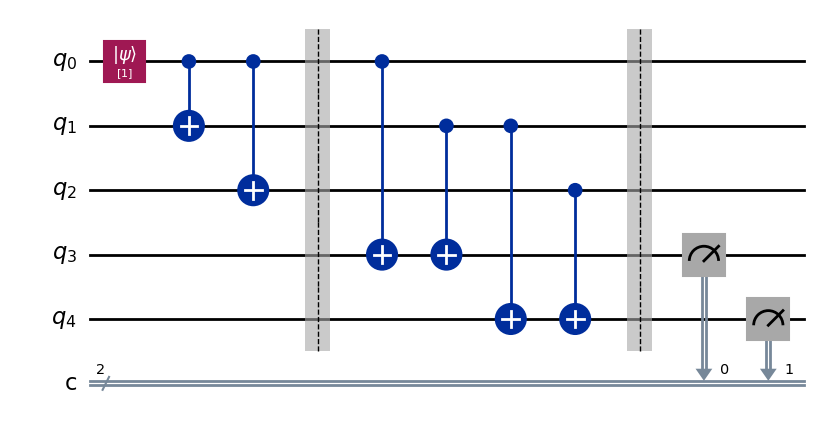

In [11]:
## SETUP
bitflip_circuit = QuantumCircuit(5,2) #5 qubits and a 2-bit resgister for the measurement of the ancilla qubits

## STEP 1: call to encoding function
encoding(bitflip_circuit, 0, 1, 2) ## 4 arguments: circuit, indexs of qubits used for the encoding

## STEP 2:call to detection function
detection(bitflip_circuit, 0, 1, 2, 3, 4) ## 6 arguments: circuit, indexs of qubits involved in the detection part

bitflip_circuit.draw()

<h4 style="font-size: 17px">&#128211;Checking the results (0,5 points) </h4>

In order to check that the circuit is working properly, we can use the statevector simulator.

<p>&#128211; What are the states of $|q_3\rangle$ and $|q_4\rangle$ (ancilla qubits) and why?
    
<p>&#128211; What are the states of $|q_0\rangle$, $|q_1\rangle$ and $|q_2\rangle$? Or in other words, what is the state of the logical qubit $|\psi_L \rangle = |q_2q_1q_0\rangle$?

**Your answer:** They are both zeros because they check if q0 and q1 and q1 and q2 have the same value - if they have, the state of the qubits will remain |0>

The state of the qubit $|\psi_L \rangle = |111\rangle$ because of the CNOT gates from q0 (which was intialized as 1) to q1 and q2

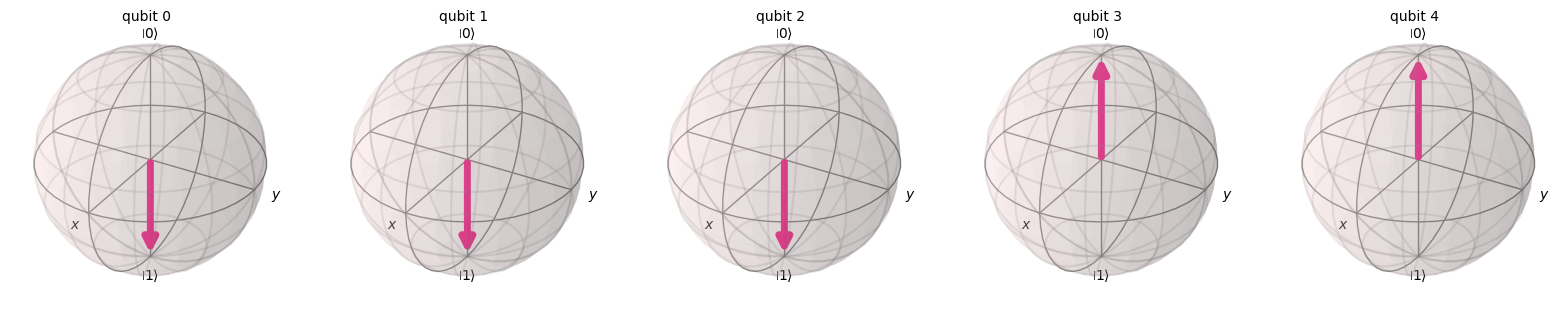

In [12]:
sv_sim = Aer.get_backend('statevector_simulator')
out_vector = sv_sim.run(bitflip_circuit).result().get_statevector()
plot_bloch_multivector(out_vector)


<h3 style="font-size: 20px"> 2. Injecting bit-flip errors and decoding them </h3>



We will now create a function that we will use to inject a single bit-flip error on $q_0$ or on $q_1$ or on $q_2$ (single error injection). Please, write the corrresponding Python code.

In [49]:
def error_injection(qc, d0, d1, d2):
    #function for injecting a bit-flip on q0, or on q1 or on q3

    #### your code goes here
    #bit-flip on q0
    qc.x(d0)

    #bit-flip on q1
    #qc.x(d1)

    #bit-flip on q2
    #qc.x(d2)


    qc.barrier()

<h4 style="font-size: 17px">&#128211;Putting all parts together (again) </h4>

Now we are ready for putting all parts together, including the error_injection fuction and run the bit-flip circuit.

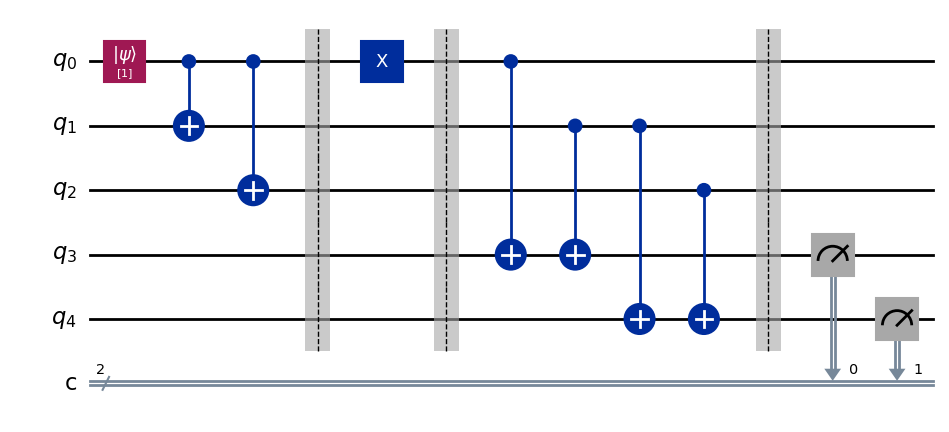

In [50]:
## SETUP

bitflip_circuit = QuantumCircuit(5,2)

## STEP 1: encoding
encoding(bitflip_circuit, 0, 1, 2)

## STEP 2: inserting errors
error_injection(bitflip_circuit, 0, 1, 2)

## STEP 3:detection
detection(bitflip_circuit, 0, 1, 2, 3, 4)


bitflip_circuit.draw()

<h4 style="font-size: 17px">&#128211;Checking the results (1 point) </h4>

Show what is the state of $|q_0\rangle$, $|q_1\rangle$, $|q_2\rangle$, $|q_3\rangle$ and $|q_4\rangle$ when injecting a single X error on: a) q0, b) q1 and c) q2. Fill in the following table based on the error syndromes you obtained in each case (LUT for the decoding of errors).

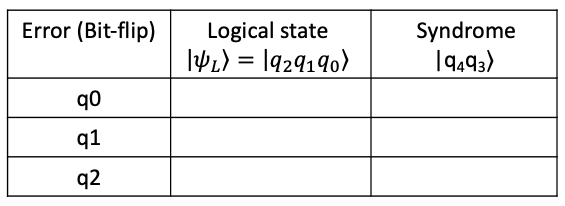


#### **Syndrome Bit-Flip Table**

| Error (Bit-flip) |  Logical state | Syndrome (q4q3) |
| :---------------- | :-------------: | :-------------: |
| $q_0$             |      I110⟩      |      I01⟩ |   
| $q_1$             |      I101⟩      |      I11⟩|  
| $q_2$             |      I011⟩      |      I10⟩|

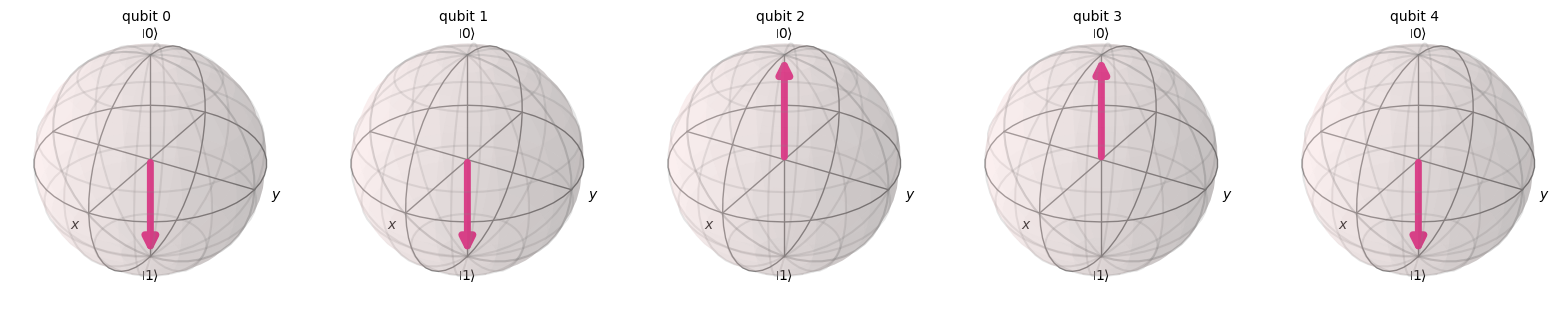

In [42]:
sv_sim = Aer.get_backend('statevector_simulator')
out_vector = sv_sim.run(bitflip_circuit).result().get_statevector()
plot_bloch_multivector(out_vector)

<h3 style="font-size: 20px"> 3. Correcting bit-flip errors </h3>



Based on the obtained error syndromes, propose a common correction circuit which fixes all the single bit-flip errors. We will create a function named “correction” that we will add as STEP 4, after the decoding part.


In [45]:
def correction(qc, d0, d1, d2, a0, a1):
     #### your code goes here

     # Correct bit-flip on q0 (syndrome 01: a1=0, a0=1)
     qc.x(a1)
     qc.ccx(a0, a1, d0)
     qc.x(a1)

     # Correct bit-flip on q1 (syndrome 11: a1=1, a0=1)
     qc.ccx(a0, a1, d1)

     # Correct bit-flip on q2 (syndrome 10: a1=1, a0=0)
     qc.x(a0)
     qc.ccx(a0, a1, d2)
     qc.x(a0)

     qc.barrier()

<h4 style="font-size: 17px">&#128211;Putting all parts together (one more time) </h4>

Let's put all parts together, including the correction fuction and run the bit-flip circuit.

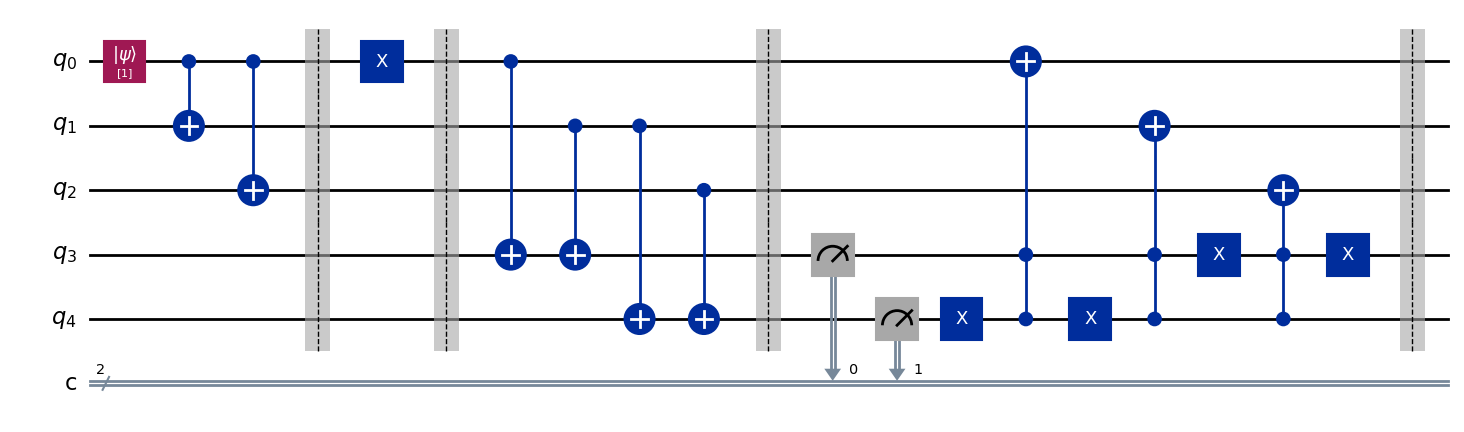

In [51]:
## SETUP
bitflip_circuit = QuantumCircuit(5,2)

## STEP 1: encoding
encoding(bitflip_circuit, 0, 1, 2)

## STEP 2: inserting errors
error_injection(bitflip_circuit,0,1,2)

## STEP 3:detection
detection(bitflip_circuit, 0, 1, 2, 3, 4)

## STEP 4:correction
correction(bitflip_circuit, 0,1,2,3,4)

bitflip_circuit.draw()

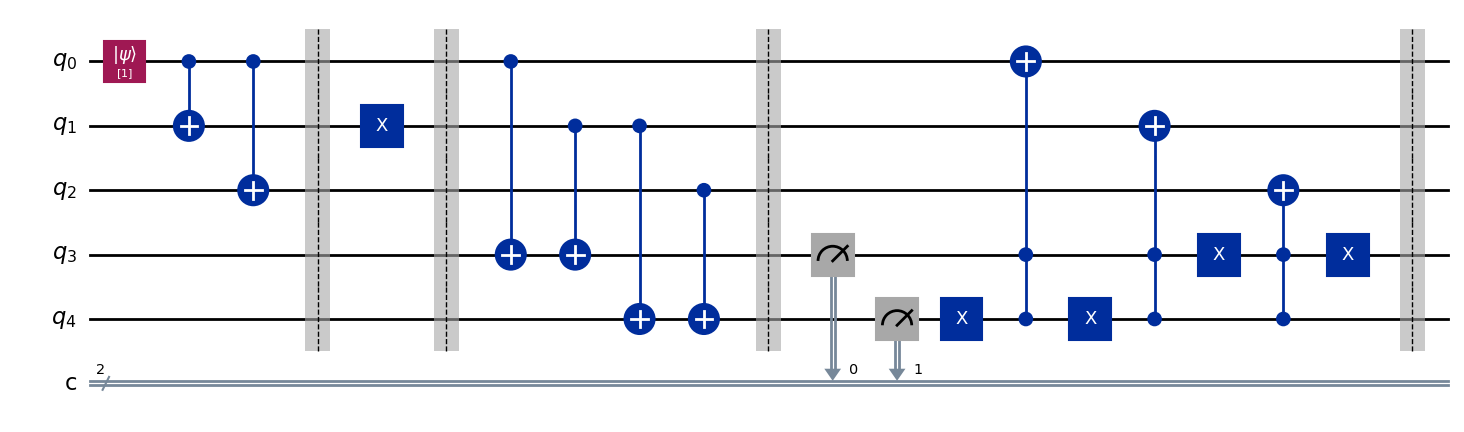

In [53]:
def error_injection_q1(qc, d0, d1, d2):
    #function for injecting a bit-flip on q0, or on q1 or on q3

    #### your code goes here
    #bit-flip on q0
    #qc.x(d0)

    #bit-flip on q1
    qc.x(d1)

    #bit-flip on q2
    #qc.x(d2)


    qc.barrier()

## SETUP
bitflip_circuit2 = QuantumCircuit(5,2)

## STEP 1: encoding
encoding(bitflip_circuit2, 0, 1, 2)

## STEP 2: inserting errors
error_injection_q1(bitflip_circuit2,0,1,2)

## STEP 3:detection
detection(bitflip_circuit2, 0, 1, 2, 3, 4)

## STEP 4:correction
correction(bitflip_circuit2, 0,1,2,3,4)

bitflip_circuit2.draw()



<h4 style="font-size: 17px">&#128211;Checking the results (1 point) </h4>

Show the state of $|q_0\rangle$, $|q_1\rangle$, $|q_2\rangle$, $|q_3\rangle$ and $|q_4\rangle$ when injecting a single X error on: a) q0, b) q1 and the errors are corrected. Show a picture of the Bloch sphere for each case.



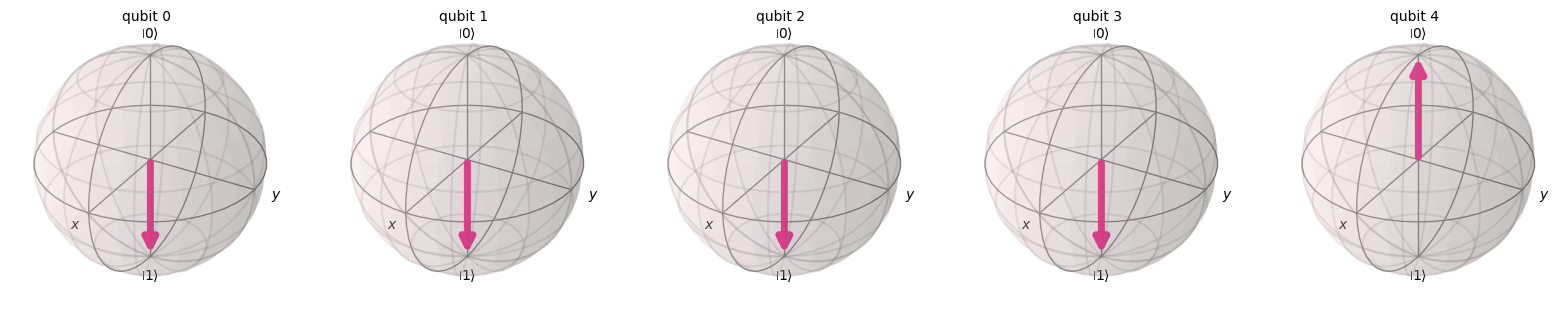

In [54]:
# q0 error

sv_sim = Aer.get_backend('statevector_simulator')
out_vector = sv_sim.run(bitflip_circuit).result().get_statevector()
plot_bloch_multivector(out_vector)

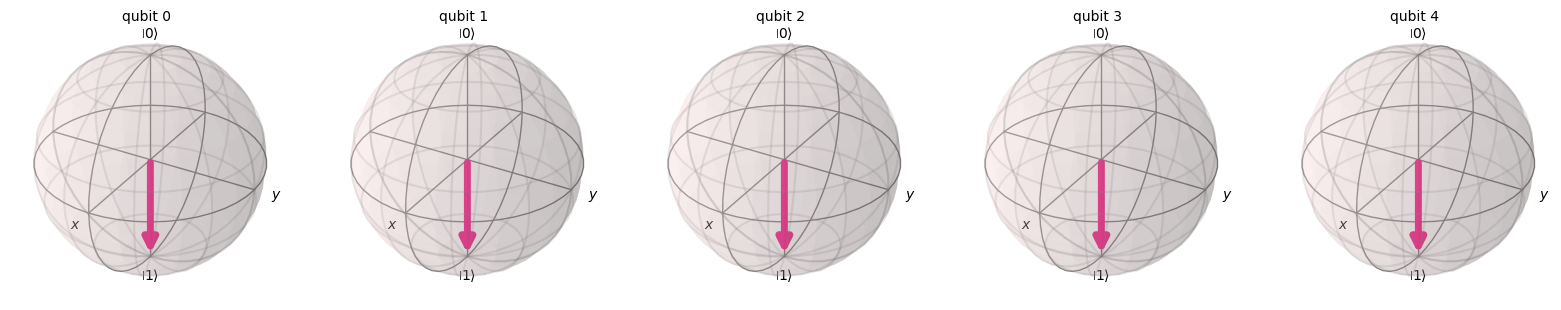

In [55]:
#q1 error

sv_sim = Aer.get_backend('statevector_simulator')
out_vector = sv_sim.run(bitflip_circuit2).result().get_statevector()
plot_bloch_multivector(out_vector)

<h2 style="font-size:24px;">The 3 qubit phase-flip code</h2>

<br>
<div style="background: #E8E7EB; border-radius: 5px;
-moz-border-radius: 5px;">
  <p style="background: #800080;
            border-radius: 5px 5px 0px 0px;
            padding: 10px 0px 10px 10px;
            font-size:18px;
            color:white;
            "><b>Goal</b></p>
    <p style=" padding: 0px 0px 10px 10px;
              font-size:16px;">Understand how the 3 qubit phase-flip code works.</p>
</div>


We are now going to repeat all steps of previous exercise but for the 3 qubit phase-flip code.

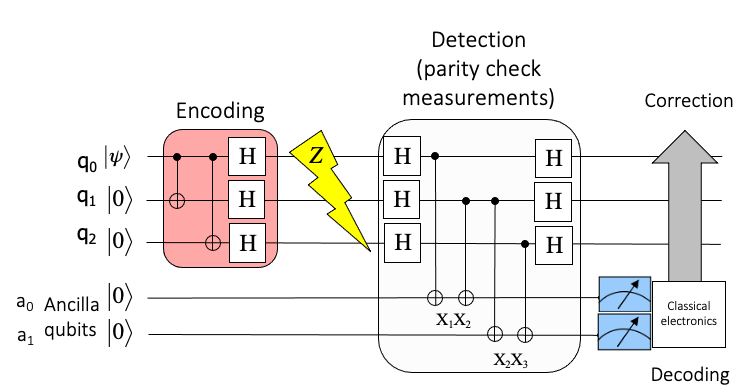

<h4 style="font-size: 17px">&#128211;Step 1. Encoding a logical qubit (0,5 points)</h4>

We will start by creating a Python function for the encoding part, in which we will initialize q0 to $|\psi \rangle = |1\rangle$ and encode it to a logical qubit $|\psi_L \rangle = |---\rangle$.

In [179]:
def encoding(qc, d0, d1, d2):
    #### your code goes here
    qc.x(d0)
    qc.cx(d0,d1)
    qc.cx(d0,d2)

    qc.h(d0)
    qc.h(d1)
    qc.h(d2)

    qc.barrier()

<h4 style="font-size: 17px">&#128211;Step 2. Injecting phase-flip errors. </h4>

Create a function to inject a single phase-flip error on q0 or q1 or q2.

In [180]:
def error_injection(qc, d0, d1, d2):
#function for injecting a phase-flip on q0, or on q1 or on q2

     #### your code goes here
    #phase-flip on q0
    #qc.z(d0)

    #phase-flip on q1
    #qc.z(d1)

    #phase-flip on q2
    #qc.z(d2)
    qc.barrier()

<h4 style="font-size: 17px">&#128211;Step 3. Detecting phase-flip errors (0,5 points)</h4>

Now, we will create another Pyhton function for the detection part as shown in the picture above.

In [181]:
def detection(qc, d0, d1, d2, a0, a1):

     #### your code goes here
    qc.h(d0)
    qc.h(d1)
    qc.h(d2)
    qc.cx(d0,a0)
    qc.cx(d1,a0)
    qc.cx(d1,a1)
    qc.cx(d2,a1)
    qc.h(d0)
    qc.h(d1)
    qc.h(d2)

    qc.barrier()

    #measurement ancilla qubit

     #### your code goes here

    qc.measure(a0,0)
    qc.measure(a1,1)


<h4 style="font-size: 17px">&#128211;Step 4. Correcting phase-flip errors (0,5 points) </h4>

As we did before, based on the obtained error syndromes, propose a common correction circuit which fix all the single phase-flip errors.

In [193]:
def correction(qc, d0, d1, d2, a0, a1):

     #### your code goes here

   # Correct phase-flip on q0 (syndrome 01: a1=0, a0=1)
     qc.x(a1)
     qc.ccz(a0, a1, d0)
     qc.x(a1)

     # Correct phase-flip on q1 (syndrome 11: a1=1, a0=1)
     qc.ccz(a0, a1, d1)

     # Correct phase-flip on q2 (syndrome 10: a1=1, a0=0)
     qc.x(a0)
     qc.ccz(a0, a1, d2)
     qc.x(a0)


     qc.barrier()

<h4 style="font-size: 17px">&#128211;Putting all parts together </h4>

Let's put all parts together.

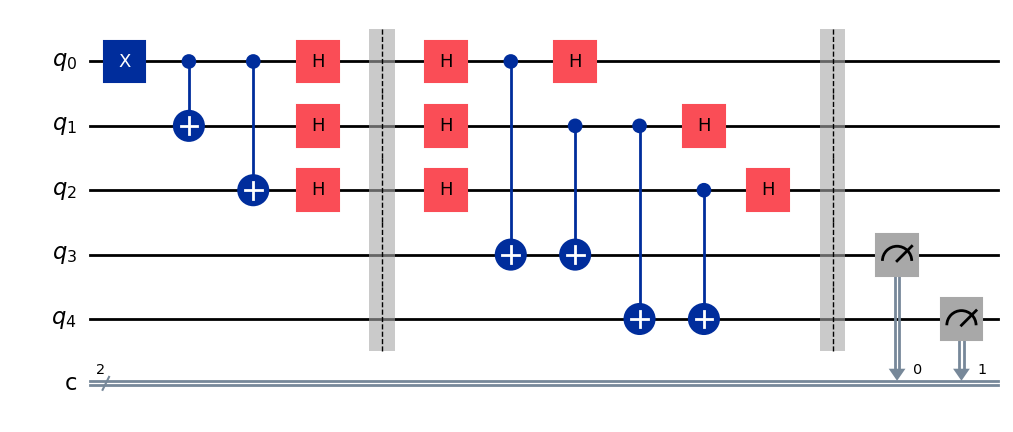

In [183]:
## SETUP
phaseflip_circuit = QuantumCircuit(5,2)

## STEP 1: encoding
encoding(phaseflip_circuit, 0, 1, 2)


## STEP 2: inserting errors

#error_injection(phaseflip_circuit, 0, 1, 2)

## STEP 3:detection

detection(phaseflip_circuit, 0, 1, 2, 3, 4)

## STEP 4:correction

#correction(phaseflip_circuit, 0, 1, 2, 3, 4)



phaseflip_circuit.draw()

<h4 style="font-size: 17px">&#128211;Checking the results (1,5 points) </h4>

Following the steps of previous section (the 3 bit-flip code) show the following:

1) In order to check that the circuit is working properly, show the state of $|q_3\rangle$ and $|q_4\rangle$ (ancilla qubits) when no errors are injected. And, what is the state of the logical qubit $|\psi_L \rangle = |q_2q_1q_0\rangle$?

2) Show the state of $|q_0\rangle$, $|q_1\rangle$, $|q_2\rangle$, $|q_3\rangle$ and $|q_4\rangle$ when injecting a single Z error in: a) q0, b) q1 and c) q2. Please, write down the error syndromes you obtained in each case (as the table you filled in before).


3) Show the state of $|q_0\rangle$, $|q_1\rangle$, $|q_2\rangle$, $|q_3\rangle$ and $|q_4\rangle$ when injecting a single Z error on: a) q0, b) q1 and c)q2 and the errors are corrected. Show a picture of the Bloch spheres for each case.



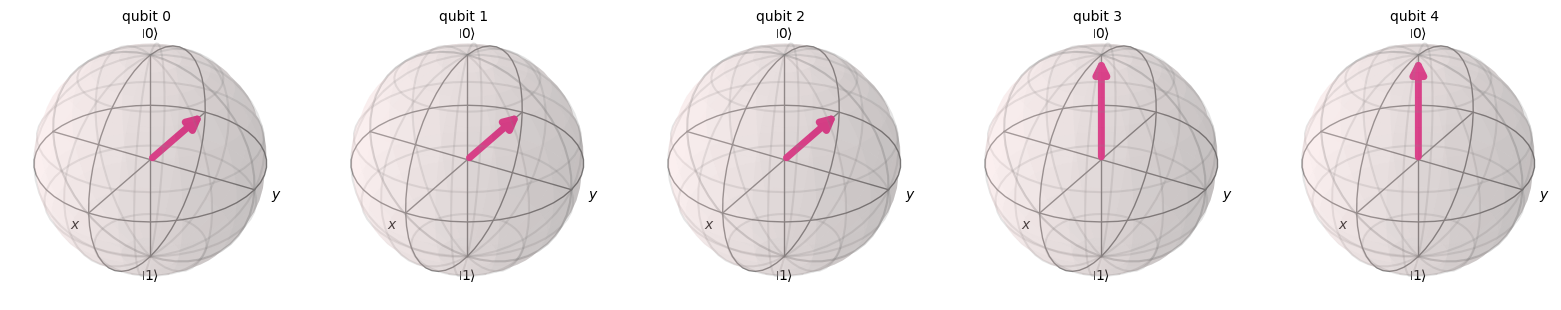

In [184]:
#1

sv_sim = Aer.get_backend('statevector_simulator')
out_vector = sv_sim.run(phaseflip_circuit).result().get_statevector()
plot_bloch_multivector(out_vector)


Logical state of the cubit is $|\psi_L \rangle = |- --\rangle$

In [185]:
def error_injection_q0(qc, d0, d1, d2):
#function for injecting a phase-flip on q0, or on q1 or on q2

     #### your code goes here
    #phase-flip on q0
    qc.z(d0)

    #phase-flip on q1
    #qc.z(d1)

    #phase-flip on q2
    #qc.z(d2)
    qc.barrier()

def error_injection_q1(qc, d0, d1, d2):
#function for injecting a phase-flip on q0, or on q1 or on q2

     #### your code goes here
    #phase-flip on q0
    #qc.z(d0)

    #phase-flip on q1
    qc.z(d1)

    #phase-flip on q2
    #qc.z(d2)
    qc.barrier()

def error_injection_q2(qc, d0, d1, d2):
#function for injecting a phase-flip on q0, or on q1 or on q2

     #### your code goes here
    #phase-flip on q0
    #qc.z(d0)

    #phase-flip on q1
    #qc.z(d1)

    #phase-flip on q2
    qc.z(d2)
    qc.barrier()

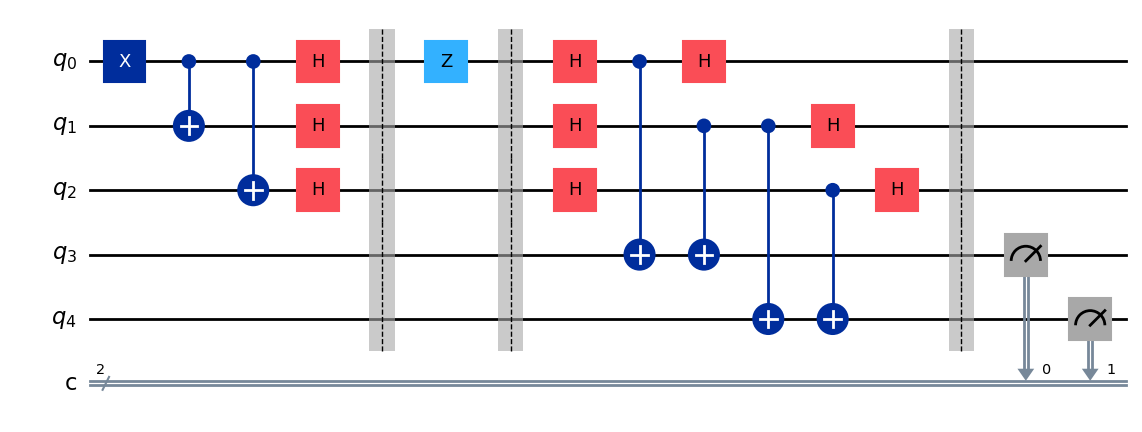

In [186]:
#2


## SETUP
phaseflip_circuit_q0 = QuantumCircuit(5,2)

## STEP 1: encoding
encoding(phaseflip_circuit_q0, 0, 1, 2)


## STEP 2: inserting errors

error_injection_q0(phaseflip_circuit_q0, 0, 1, 2)

## STEP 3:detection

detection(phaseflip_circuit_q0, 0, 1, 2, 3, 4)

phaseflip_circuit_q0.draw()


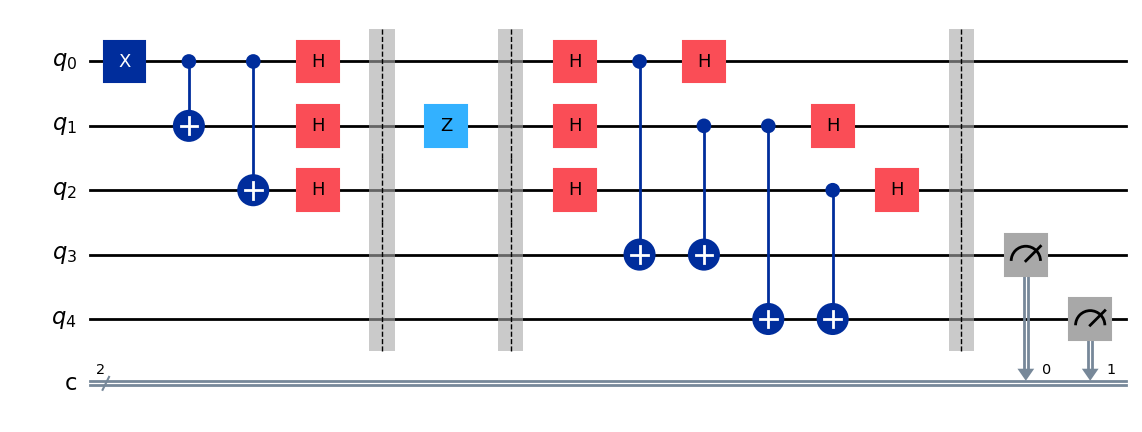

In [187]:
phaseflip_circuit_q1 = QuantumCircuit(5,2)

## STEP 1: encoding
encoding(phaseflip_circuit_q1, 0, 1, 2)


## STEP 2: inserting errors

error_injection_q1(phaseflip_circuit_q1, 0, 1, 2)

## STEP 3:detection

detection(phaseflip_circuit_q1, 0, 1, 2, 3, 4)

phaseflip_circuit_q1.draw()


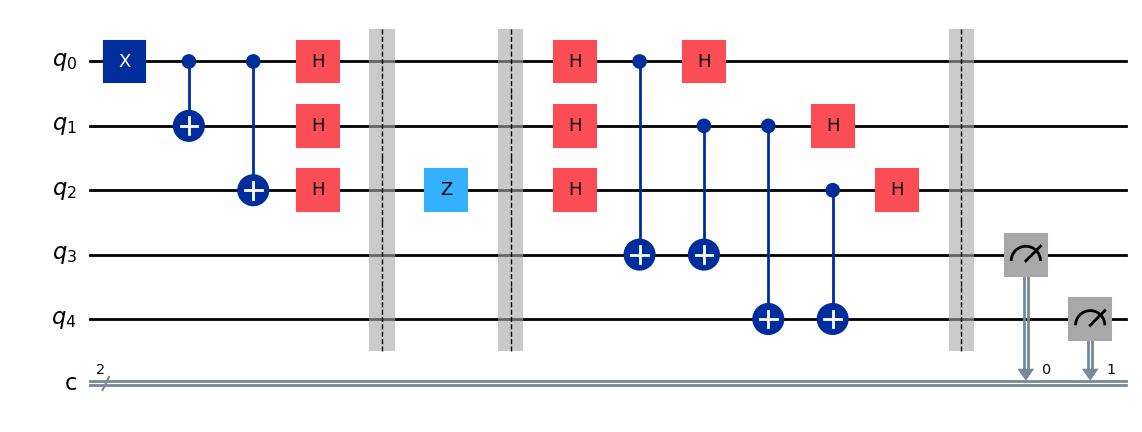

In [188]:
phaseflip_circuit_q2 = QuantumCircuit(5,2)

## STEP 1: encoding
encoding(phaseflip_circuit_q2, 0, 1, 2)


## STEP 2: inserting errors

error_injection_q2(phaseflip_circuit_q2, 0, 1, 2)

## STEP 3:detection

detection(phaseflip_circuit_q2, 0, 1, 2, 3, 4)

phaseflip_circuit_q2.draw()

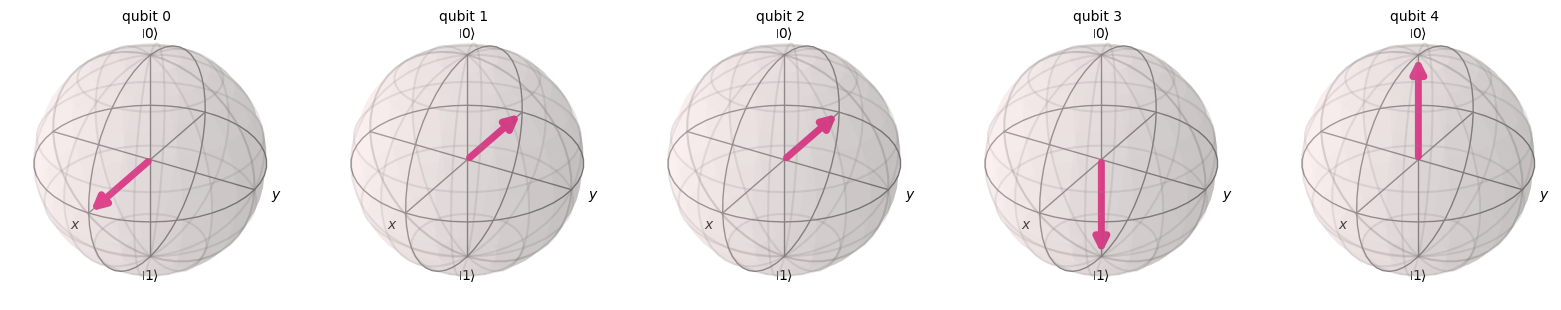

In [192]:
sv_sim = Aer.get_backend('statevector_simulator')
out_vector = sv_sim.run(phaseflip_circuit_q0).result().get_statevector()
plot_bloch_multivector(out_vector)

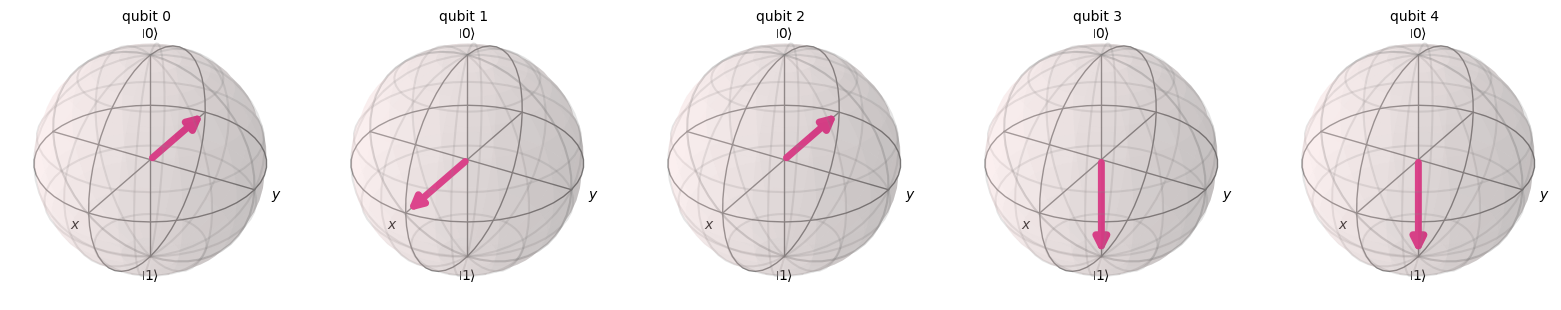

In [190]:
sv_sim = Aer.get_backend('statevector_simulator')
out_vector = sv_sim.run(phaseflip_circuit_q1).result().get_statevector()
plot_bloch_multivector(out_vector)

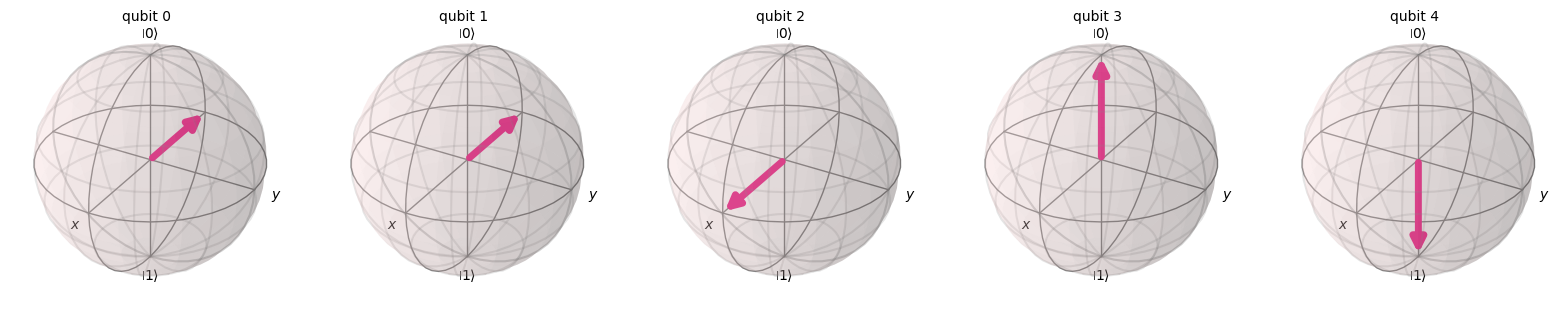

In [191]:
sv_sim = Aer.get_backend('statevector_simulator')
out_vector = sv_sim.run(phaseflip_circuit_q2).result().get_statevector()
plot_bloch_multivector(out_vector)

#### **Syndrome Phase-Flip Table**

| Error (Phase-flip) |  Logical state | Syndrome (q4q3) |
| :---------------- | :-------------: | :-------------: |
| $q_0$             |      I--+⟩      |      I01⟩ |   
| $q_1$             |      I-+-⟩      |      I11⟩|  
| $q_2$             |      I+--⟩      |      I10⟩|

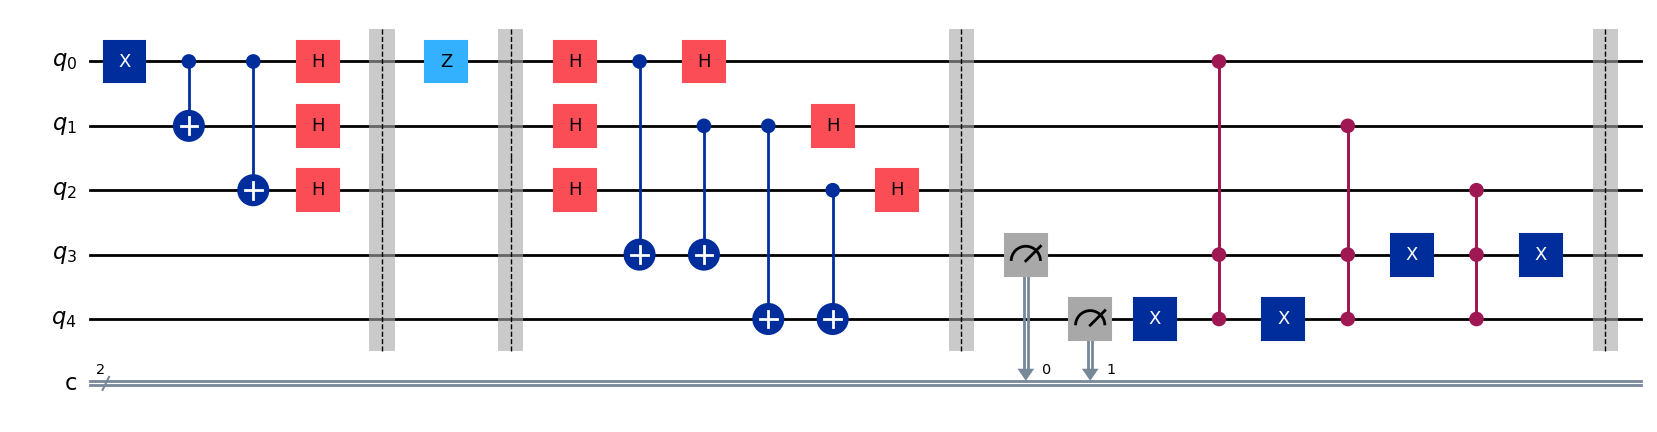

In [194]:
#3


## SETUP
phaseflip_circuit_q0 = QuantumCircuit(5,2)

## STEP 1: encoding
encoding(phaseflip_circuit_q0, 0, 1, 2)


## STEP 2: inserting errors

error_injection_q0(phaseflip_circuit_q0, 0, 1, 2)

## STEP 3:detection

detection(phaseflip_circuit_q0, 0, 1, 2, 3, 4)

correction(phaseflip_circuit_q0, 0, 1, 2, 3, 4)

phaseflip_circuit_q0.draw()

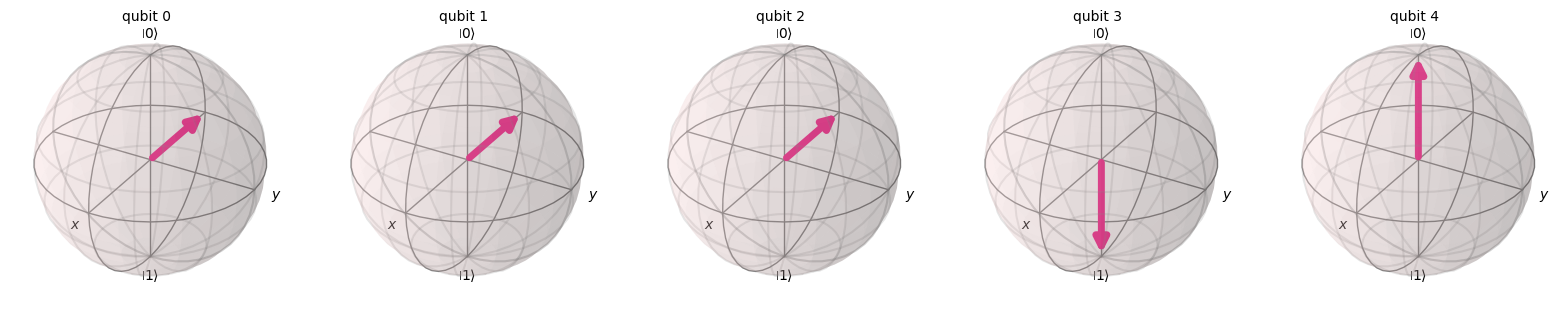

In [195]:
sv_sim = Aer.get_backend('statevector_simulator')
out_vector = sv_sim.run(phaseflip_circuit_q0).result().get_statevector()
plot_bloch_multivector(out_vector)

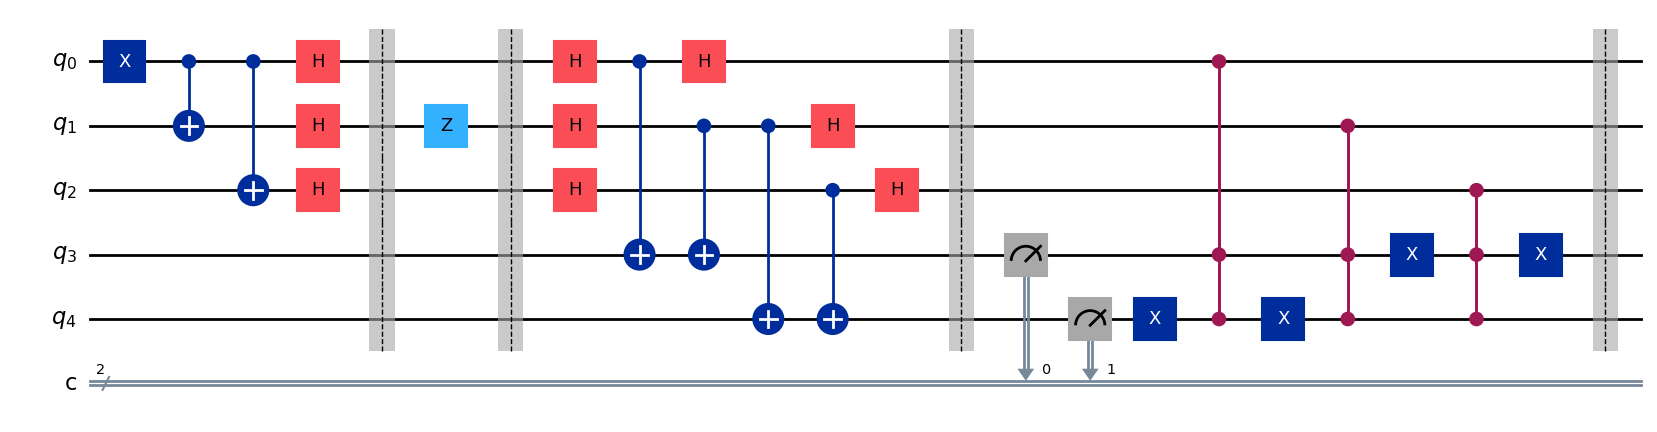

In [196]:
phaseflip_circuit_q1 = QuantumCircuit(5,2)

## STEP 1: encoding
encoding(phaseflip_circuit_q1, 0, 1, 2)


## STEP 2: inserting errors

error_injection_q1(phaseflip_circuit_q1, 0, 1, 2)

## STEP 3:detection

detection(phaseflip_circuit_q1, 0, 1, 2, 3, 4)

correction(phaseflip_circuit_q1, 0, 1, 2, 3, 4)


phaseflip_circuit_q1.draw()

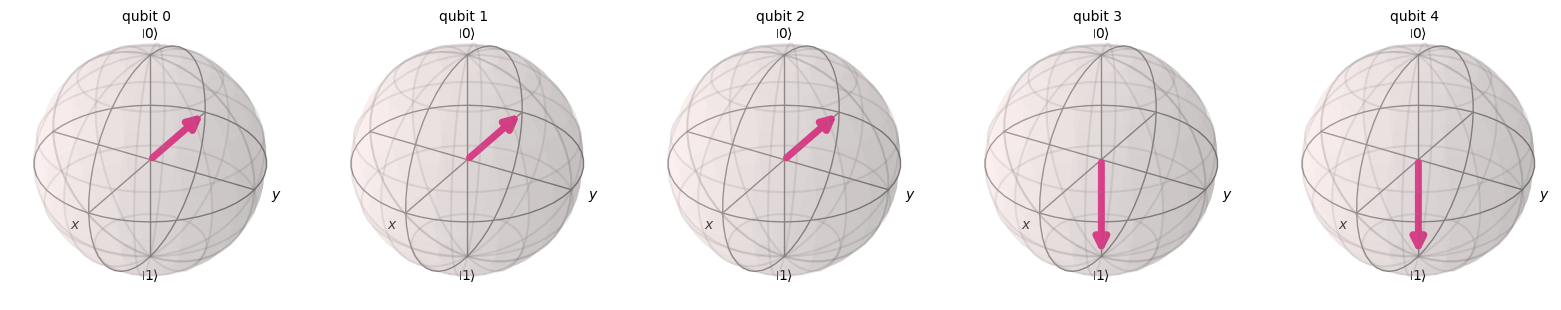

In [197]:
sv_sim = Aer.get_backend('statevector_simulator')
out_vector = sv_sim.run(phaseflip_circuit_q1).result().get_statevector()
plot_bloch_multivector(out_vector)

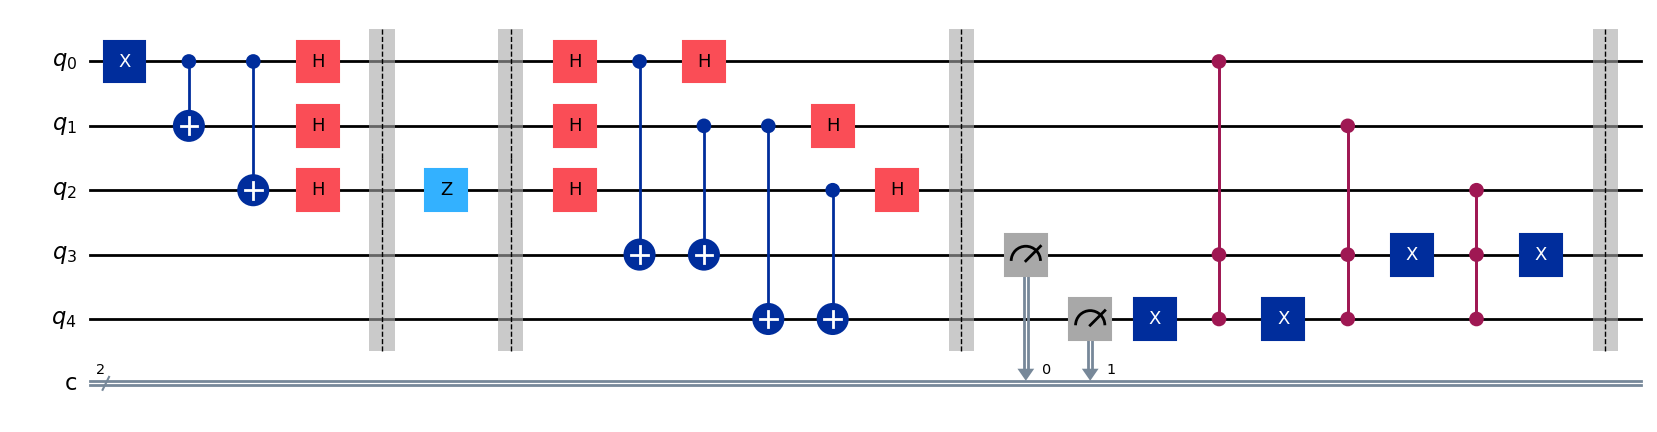

In [198]:

phaseflip_circuit_q2 = QuantumCircuit(5,2)

## STEP 1: encoding
encoding(phaseflip_circuit_q2, 0, 1, 2)


## STEP 2: inserting errors

error_injection_q2(phaseflip_circuit_q2, 0, 1, 2)

## STEP 3:detection

detection(phaseflip_circuit_q2, 0, 1, 2, 3, 4)

correction(phaseflip_circuit_q2, 0, 1, 2, 3, 4)



phaseflip_circuit_q2.draw()

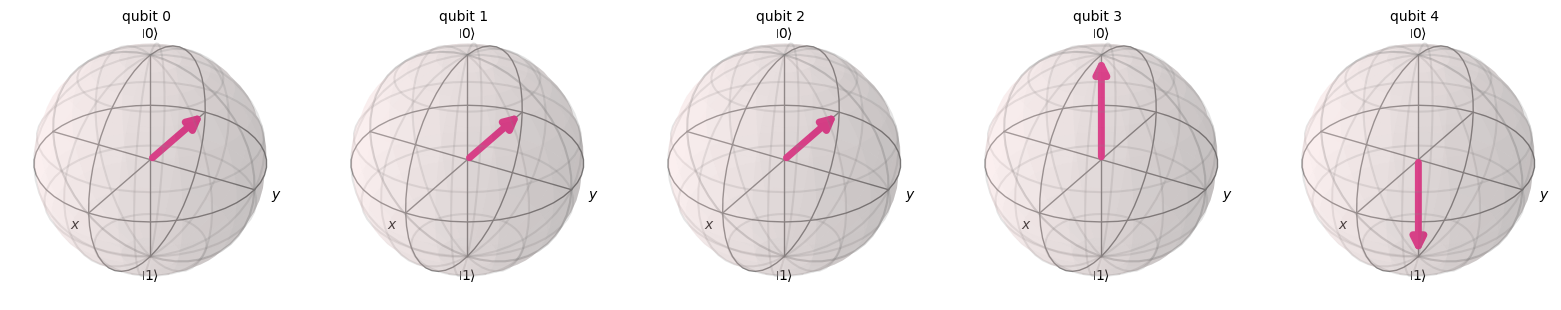

In [199]:
sv_sim = Aer.get_backend('statevector_simulator')
out_vector = sv_sim.run(phaseflip_circuit_q2).result().get_statevector()
plot_bloch_multivector(out_vector)

<h2 style="font-size:24px;">The 7 qubit Steane code</h2>

<br>
<div style="background: #E8E7EB; border-radius: 5px;
-moz-border-radius: 5px;">
  <p style="background: #800080;
            border-radius: 5px 5px 0px 0px;
            padding: 10px 0px 10px 10px;
            font-size:18px;
            color:white;
            "><b>Goal</b></p>
    <p style=" padding: 0px 0px 10px 10px;
              font-size:16px;">Understand how the 7 qubit Steane code works.</p>
</div>


During the lectures we discussed a more advanced QEC code, the 7-qubit Steane code, that can detect single bit-flip and phase-flip errors. The following Figure shows the circuit to encode a logical qubit using the 7-qubit Steane code.

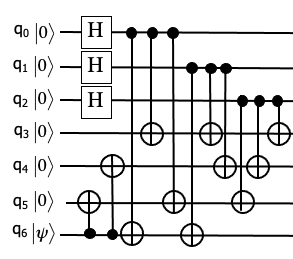

As we did in the previous exercises, we will complete the circuit with the error injection, the error detection and the decoding parts.



<h4 style="font-size: 17px">&#128211;Step 1. Encoding a logical qubit (1 point)</h4>

We will start by creating a Python function for the encoding part, in which we will initialize q6 to $|\psi \rangle = |0\rangle$ and encode its corresponding logical state.

In [210]:
def encoding(qc, d0, d1, d2, d3, d4, d5, d6):

     #### your code goes here
    qc.h(d0)
    qc.h(d1)
    qc.h(d2)

    qc.cx(d6, d5)
    qc.cx(d6, d4)
    qc.cx(d0, d6)
    qc.cx(d0, d3)
    qc.cx(d0, d5)
    qc.cx(d1, d6)
    qc.cx(d1, d3)
    qc.cx(d1, d4)
    qc.cx(d2, d5)
    qc.cx(d2, d4)
    qc.cx(d2, d3)

    qc.barrier()

<h4 style="font-size: 17px">&#128211;Step 2. Injecting phase-flip errors and bit-flip errors. </h4>

Create a function that we will use later to inject single bit-flip and phase-flip errors.

In [211]:
def error_injection(qc, d0, d1, d2, d3, d4, d5, d6, bit_flip_errors = None, phase_flip_errors = None):
#function for injecting  phase-flip  and bit-flip errors

     #### your code goes here
    data_qubits = [d0, d1, d2, d3, d4, d5, d6]

    if bit_flip_errors is None:
        bit_flip_errors = []
    if phase_flip_errors is None:
        phase_flip_errors = []

    for q in bit_flip_errors:
        qc.x(data_qubits[q])

    for q in phase_flip_errors:
        qc.z(data_qubits[q])

    qc.barrier()

<h4 style="font-size: 17px">&#128211;Step 3. Detecting bit-flip and phase-flip errors (1 point)</h4>

Now, we will create another Pyhton function for the detection part. In this case, I will not provide you with the circuit itlsef but with the stabillisers of the Steane code. As explained in the lecture, all CNOT operations performed in the detection part correspond to the stabilisers of the QEC code. For instance, in the bit-flip code the CNOTs between q1,a1 and q2,a1 represent the stabiliser $Z_1Z_2$ as shown in the slides of Tuesday's lecture.

Create the error detection circuit for the 7-qubit Steane code knowing that the following stabilizers are used  to detect bit-flip and phase-flip errors:

$s1=Z_0Z_1Z_2Z_3$

$s2=Z_0Z_1Z_4Z_5$

$s3=Z_0Z_2Z_4Z_6$

$s4=X_0X_1X_2X_3$

$s5=X_0X_1X_4X_5$

$s6=X_0X_2X_4X_6$

Use as many ancilla qubits as stabilisers, that is, 6.


In [212]:
def detection(qc, d0, d1, d2, d3, d4, d5, d6, a0, a1, a2, a3, a4, a5):

    #### your code goes here

    #Parity check0 Z0Z1Z2Z3

    qc.barrier()
    qc.cx(d0, a0)
    qc.cx(d1, a0)
    qc.cx(d2, a0)
    qc.cx(d3, a0)

    #Parity check0 Z0Z1Z4Z5


    qc.barrier()
    qc.cx(d0, a1)
    qc.cx(d1, a1)
    qc.cx(d4, a1)
    qc.cx(d5, a1)
    #Parity check0 Z0Z2Z4Z6


    qc.barrier()
    qc.cx(d0, a2)
    qc.cx(d2, a2)
    qc.cx(d4, a2)
    qc.cx(d6, a2)

    #Parity check0 X0X1X2X3




    qc.barrier()
    qc.h(a3)
    qc.cx(a3, d0)
    qc.cx(a3, d1)
    qc.cx(a3, d2)
    qc.cx(a3, d3)
    qc.h(a3)


    #Parity check0 X0X1X4X5

    qc.barrier()
    qc.h(a4)
    qc.cx(a4, d0)
    qc.cx(a4, d1)
    qc.cx(a4, d4)
    qc.cx(a4, d5)
    qc.h(a4)


    #Parity check0 X0X2X4X6


    qc.barrier()
    qc.h(a5)
    qc.cx(a5, d0)
    qc.cx(a5, d2)
    qc.cx(a5, d4)
    qc.cx(a5, d6)
    qc.h(a5)



    #measurement ancilla qubits
     #### your code goes here
    qc.measure(a0, 0)
    qc.measure(a1, 1)
    qc.measure(a2, 2)
    qc.measure(a3, 3)
    qc.measure(a4, 4)
    qc.measure(a5, 5)


<h4 style="font-size: 17px">&#128211;Putting all parts together </h4>

Let's put all parts together and build the complete circuit for the 7-qubit Steane code.

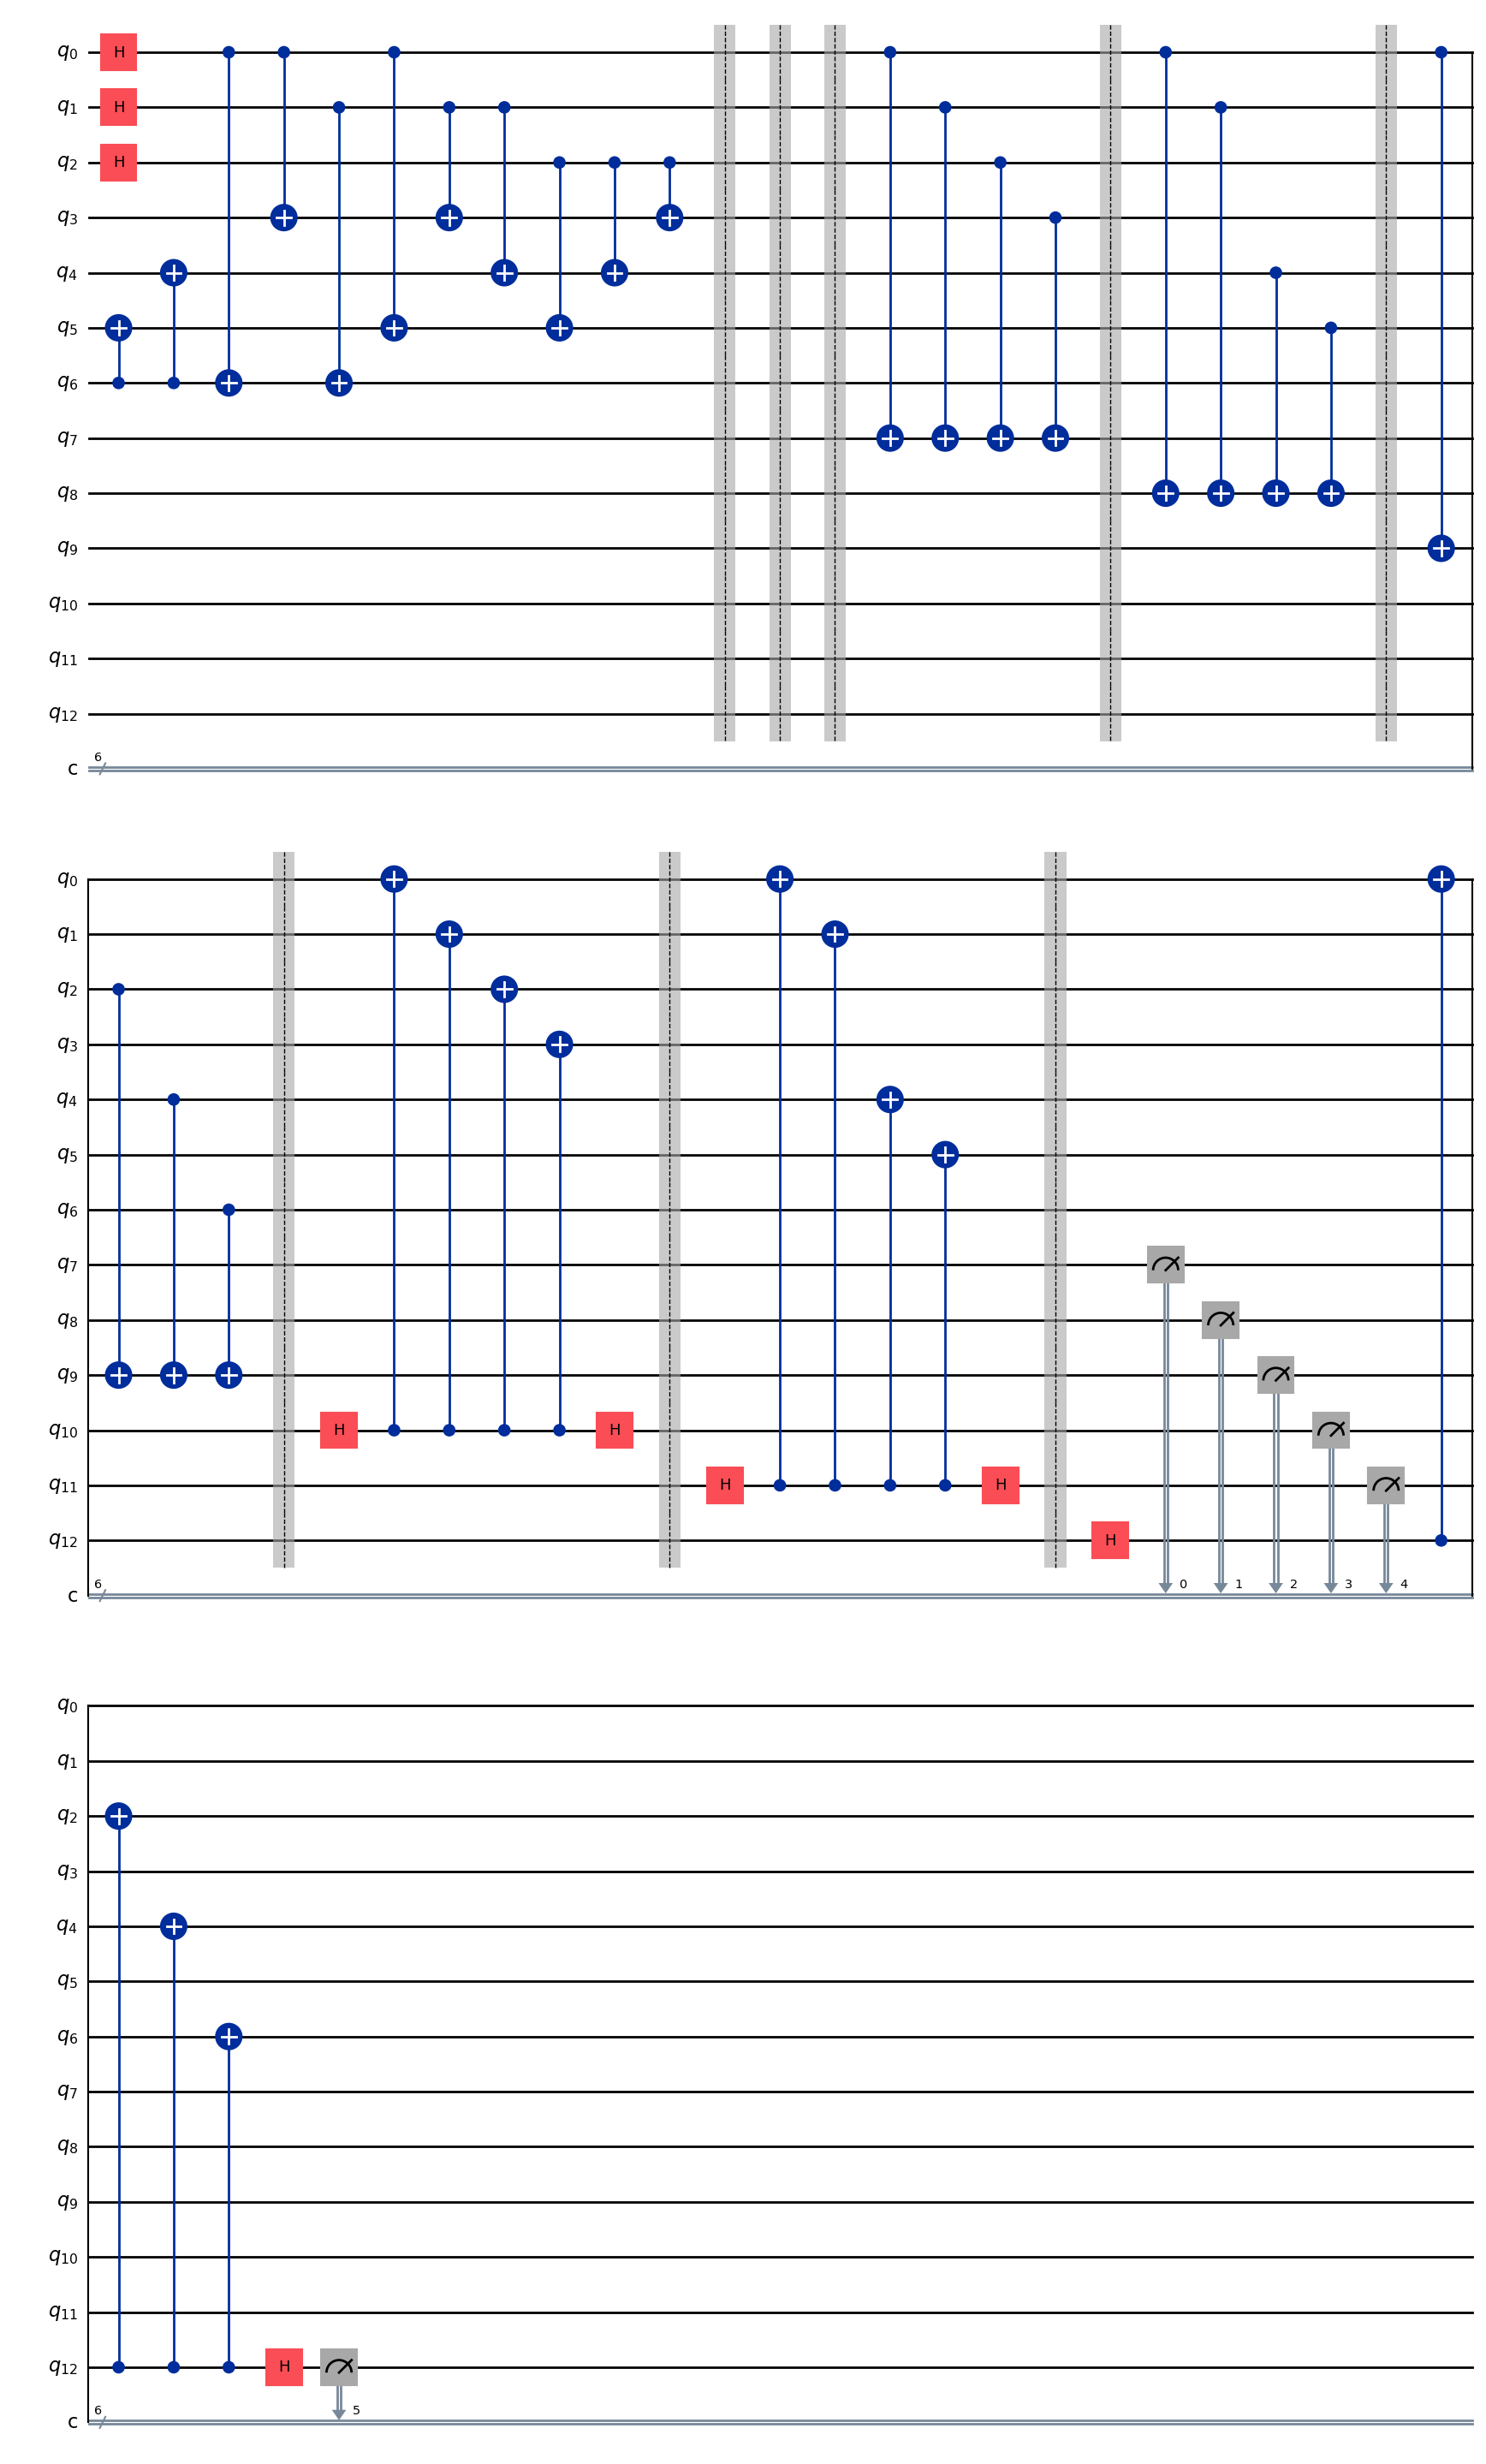

In [213]:
## SETUP
steane_circuit = QuantumCircuit(13, 6) # Initialize with 13 qubits and 6 classical bits

## STEP 1: encoding

encoding(steane_circuit, 0, 1, 2, 3, 4, 5, 6)


## STEP 2: inserting errors

error_injection(steane_circuit, 0,1,2,3,4,5,6)


## STEP 3:detection

detection(steane_circuit, 0,1,2,3,4,5,6,7,8,9,10,11,12)

steane_circuit.draw()

<h4 style="font-size: 17px">&#128211;Checking the results with no errors </h4>

In order to check that the circuit is working properly, show the outcome of the ancilla qubits when no errors are injected. In this case, we will use the qasm simulator and the 'counts' function of Qiskit as the number of qubits is too large for using the state vector simulator.



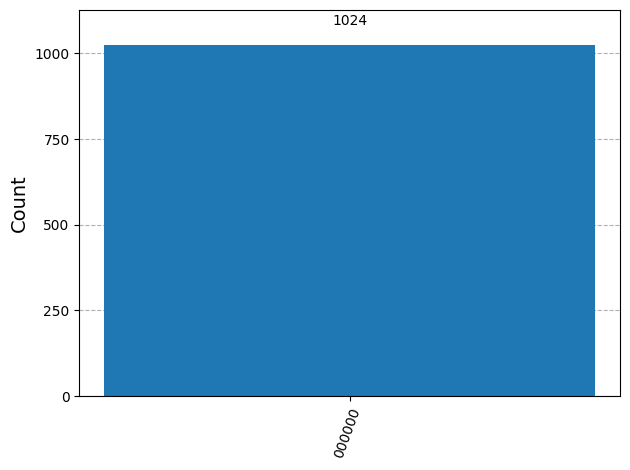

In [214]:
qasm_sim = Aer.get_backend('qasm_simulator')
t_qc = transpile(steane_circuit, qasm_sim)
results = qasm_sim.run(t_qc).result()
counts = results.get_counts()
plot_histogram(counts)

<h4 style="font-size: 17px">&#128211;Checking the results with errors (1,5 points) </h4>

Now we will inject different single bit-flip and phase-flip errors and see how the ancilla outcomes (error syndromes) will change. To this purspose, inject the following  bit-flip and phase-flip errors and write down the observed error syndromes.

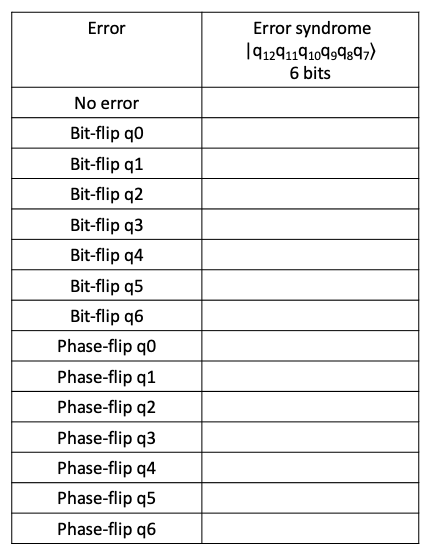


In [234]:
def run_steane_circuit(bit_flip_errors=None, phase_flip_errors=None):
    qc = QuantumCircuit(13, 6)
    encoding(qc, 0, 1, 2, 3, 4, 5, 6)
    error_injection(qc, 0, 1, 2, 3, 4, 5, 6, bit_flip_errors, phase_flip_errors)
    detection(qc, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)

    qasm_sim = Aer.get_backend('qasm_simulator')
    t_qc = transpile(qc, qasm_sim)
    results = qasm_sim.run(t_qc).result()
    counts = results.get_counts()
    return counts

print("No error", run_steane_circuit())
for i in range (0,7):
  print("Bit flip q",i,run_steane_circuit([i], None))

for i in range (0,7):
  print("Phase flip q",i,run_steane_circuit(None, [i]))

No error {'000000': 1024}
Bit flip q 0 {'000111': 1024}
Bit flip q 1 {'000011': 1024}
Bit flip q 2 {'000101': 1024}
Bit flip q 3 {'000001': 1024}
Bit flip q 4 {'000110': 1024}
Bit flip q 5 {'000010': 1024}
Bit flip q 6 {'000100': 1024}
Phase flip q 0 {'111000': 1024}
Phase flip q 1 {'011000': 1024}
Phase flip q 2 {'101000': 1024}
Phase flip q 3 {'001000': 1024}
Phase flip q 4 {'110000': 1024}
Phase flip q 5 {'010000': 1024}
Phase flip q 6 {'100000': 1024}


<p>&#128211; What is the error syndrome if we inject a bit-flip error on q0 and a phase flip error on q6? Are these errors detectable and correctable?

In [235]:
print(run_steane_circuit([0], [6]))

{'100111': 1024}


**Your answer:** 100111. Yes, these are detectable and correctable because bit flips affect q7 - q9 and phase flips q10 - q12.

<p>&#128211; What is the error syndrome if we inject two bit-flip errors simultaneously, one on q0 and another on q1? Are these errors detectable and correctable? Why?

In [236]:
print(run_steane_circuit([0,1], None))

{'000100': 1024}


**Your answer:** They are detectable, but they are not correctable (it shares the same error syndrome as q6 bit flip)